In [ ]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [2]:
import torch
torch.cuda.is_available()

True

In [18]:
# Split the dataset on folder dataset_indonesian_car_scrape into train, test, and validation folders
# We will use pytorch later to fine tune the model
# Make sure to use the correct PyTorch ImageFolder format where class names are folder names

import os
import shutil
import numpy as np

# Set the path to the dataset
dataset_path = 'Dataset_Mobil_Indonesia_Balanced_backup_cleaned_sampled_100'

# Get the list of all subdirectories in the dataset (these are our class labels)
subdirs = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

# Create train, test, and validation directories
train_dir = os.path.join(dataset_path, 'train')
test_dir = os.path.join(dataset_path, 'test')
val_dir = os.path.join(dataset_path, 'val')

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# Define split ratios
train_ratio = 0.7
test_ratio = 0.2
val_ratio = 0.1

# Process each subdirectory (car brand/class)
for subdir in subdirs:
    if subdir in ['train', 'test', 'val']:  # Skip if these directories already exist
        continue
        
    subdir_path = os.path.join(dataset_path, subdir)
    images = [f for f in os.listdir(subdir_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    # Shuffle the images
    np.random.seed(42)  # For reproducibility
    np.random.shuffle(images)
    
    # Calculate split indices
    train_count = int(len(images) * train_ratio)
    test_count = int(len(images) * test_ratio)
    
    # Split images
    train_images = images[:train_count]
    test_images = images[train_count:train_count + test_count]
    val_images = images[train_count + test_count:]
    
    # Create class subdirectories in train, test, val folders
    # This maintains the PyTorch ImageFolder structure: train/class_name/images
    train_class_dir = os.path.join(train_dir, subdir)
    test_class_dir = os.path.join(test_dir, subdir)
    val_class_dir = os.path.join(val_dir, subdir)
    
    os.makedirs(train_class_dir, exist_ok=True)
    os.makedirs(test_class_dir, exist_ok=True)
    os.makedirs(val_class_dir, exist_ok=True)
    
    # Copy images to respective directories
    for img in train_images:
        src = os.path.join(subdir_path, img)
        dst = os.path.join(train_class_dir, img)
        shutil.copy2(src, dst)
    
    for img in test_images:
        src = os.path.join(subdir_path, img)
        dst = os.path.join(test_class_dir, img)
        shutil.copy2(src, dst)
    
    for img in val_images:
        src = os.path.join(subdir_path, img)
        dst = os.path.join(val_class_dir, img)
        shutil.copy2(src, dst)
    
    print(f"Split {subdir}: {len(train_images)} train, {len(test_images)} test, {len(val_images)} val")

print("Dataset split completed!")
print("\nPyTorch ImageFolder structure created:")
print(f"- {train_dir}/class_name/images")
print(f"- {test_dir}/class_name/images") 
print(f"- {val_dir}/class_name/images")
print("\nThis format is compatible with torchvision.datasets.ImageFolder")


Split Sedan: 70 train, 20 test, 10 val
Split Pick-up: 70 train, 20 test, 10 val
Split Hatchback: 69 train, 19 test, 11 val
Split Truk: 65 train, 18 test, 11 val
Split MPV: 64 train, 18 test, 10 val
Split Double Cabin: 70 train, 20 test, 10 val
Split LCGC: 60 train, 17 test, 9 val
Split SUV: 70 train, 20 test, 10 val
Split City Car: 56 train, 16 test, 8 val
Split Van: 70 train, 20 test, 10 val
Dataset split completed!

PyTorch ImageFolder structure created:
- Dataset_Mobil_Indonesia_Balanced_backup_cleaned_sampled_100/train/class_name/images
- Dataset_Mobil_Indonesia_Balanced_backup_cleaned_sampled_100/test/class_name/images
- Dataset_Mobil_Indonesia_Balanced_backup_cleaned_sampled_100/val/class_name/images

This format is compatible with torchvision.datasets.ImageFolder


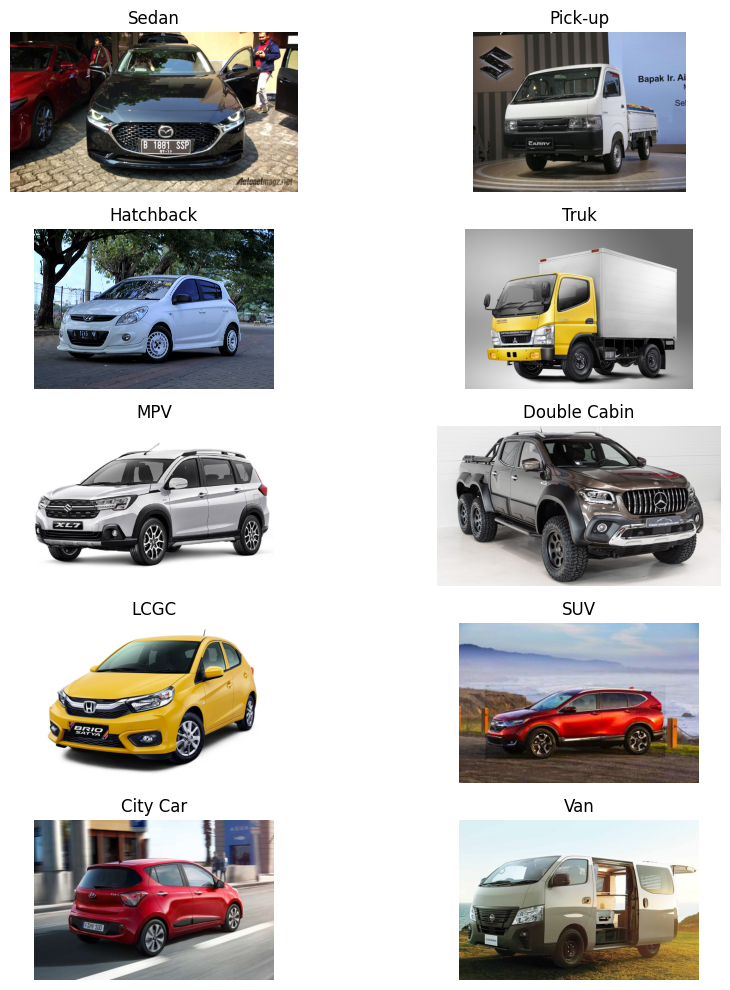

In [14]:
# I want to create visualization of my training images

import os
import matplotlib.pyplot as plt
import numpy as np

# Set the path to the training images
train_dir = 'Dataset_Mobil_Indonesia_Balanced_backup'

# Get the list of all subdirectories in the training directory
subdirs = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

# Create a figure with subplots based on number of subdirectories
num_subdirs = len(subdirs)
cols = min(num_subdirs, 2)  # Max 2 columns
rows = (num_subdirs + cols - 1) // cols  # Calculate rows needed

fig, axs = plt.subplots(rows, cols, figsize=(10, 10))

# Ensure axs is always 2D array for consistent indexing
if num_subdirs == 1:
    axs = np.array([[axs]])
elif rows == 1:
    axs = axs.reshape(1, -1)

# Loop through each subdirectory and plot one sample image
for i, subdir in enumerate(subdirs):
    subdir_path = os.path.join(train_dir, subdir)
    images = [f for f in os.listdir(subdir_path) if f.endswith('.jpg')]
    
    if images:  # Make sure there are images in the directory
        # Take the first image as sample
        image = images[0]
        image_path = os.path.join(subdir_path, image)
        img = plt.imread(image_path)
        
        row = i // cols
        col = i % cols
        axs[row, col].imshow(img)
        axs[row, col].set_title(f'{subdir}', fontsize=12)
        axs[row, col].axis('off')

# Hide any unused subplots
for i in range(num_subdirs, rows * cols):
    row = i // cols
    col = i % cols
    axs[row, col].axis('off')

plt.tight_layout()
plt.savefig('train_images.png')
plt.show()

# Export


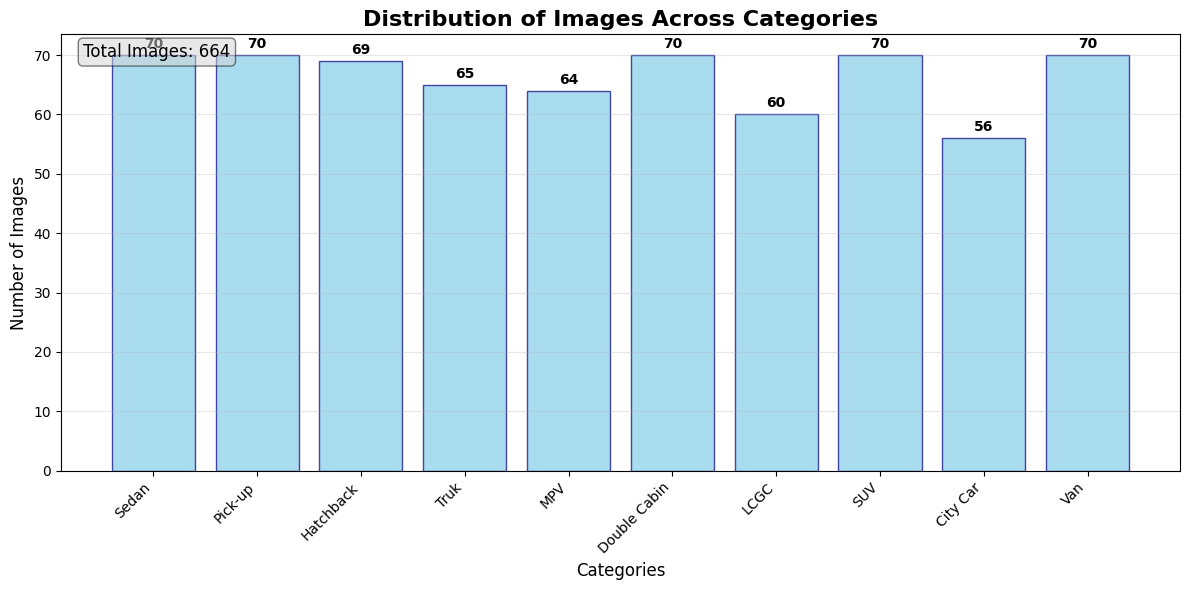


Dataset Summary:
Total Categories: 10
Total Images: 664
Average Images per Category: 66.4

Detailed Distribution:
Sedan: 70 images (10.5%)
Pick-up: 70 images (10.5%)
Double Cabin: 70 images (10.5%)
SUV: 70 images (10.5%)
Van: 70 images (10.5%)
Hatchback: 69 images (10.4%)
Truk: 65 images (9.8%)
MPV: 64 images (9.6%)
LCGC: 60 images (9.0%)
City Car: 56 images (8.4%)


In [21]:
# Now Visualization of the Image Distribution

# Count the number of images in each subdirectory
image_counts = {}
for subdir in subdirs:
    subdir_path = os.path.join(train_dir, subdir)
    images = [f for f in os.listdir(subdir_path) if f.endswith('.jpg')]
    image_counts[subdir] = len(images)

# Create a bar plot for image distribution
plt.figure(figsize=(12, 6))
categories = list(image_counts.keys())
counts = list(image_counts.values())

bars = plt.bar(categories, counts, color='skyblue', edgecolor='navy', alpha=0.7)

# Add value labels on top of each bar
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01, 
             str(count), ha='center', va='bottom', fontweight='bold')

plt.title('Distribution of Images Across Categories', fontsize=16, fontweight='bold')
plt.xlabel('Categories', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add total count text
total_images = sum(counts)
plt.text(0.02, 0.98, f'Total Images: {total_images}', 
         transform=plt.gca().transAxes, fontsize=12, 
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5),
         verticalalignment='top')

plt.tight_layout()
plt.savefig('image_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\nDataset Summary:")
print(f"Total Categories: {len(categories)}")
print(f"Total Images: {total_images}")
print(f"Average Images per Category: {total_images/len(categories):.1f}")
print(f"\nDetailed Distribution:")
for category, count in sorted(image_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = (count / total_images) * 100
    print(f"{category}: {count} images ({percentage:.1f}%)")
